# 📊 Exploratory Data Analysis — Bank Marketing Dataset

---

**Source:** Direct marketing campaigns (phone calls) of a Portuguese banking institution  
**Goal:** Predict whether a client will subscribe a **term deposit** → target variable `y` (`yes` / `no`)  
**Dataset:** `bank-additional-full.csv` · 41,188 records · 20 features · May 2008 – Nov 2010

| Property | Value |
|---|---|
| Instances | 41,188 |
| Features | 20 |
| Feature Types | Categorical, Integer, Float |
| Task | Binary Classification |

---

## 🌍 Key Economic / Social Features

| Feature | Description | Impact on Deposit |
|---|---|---|
| `emp.var.rate` | Employment Variation Rate (+ve = growth, −ve = job losses) | Job losses → clients avoid locking money in deposits |
| `cons.price.idx` | Consumer Price Index — measures inflation over time | High inflation → clients may prefer other investments |
| `cons.conf.idx` | Consumer Confidence Index — how optimistic people feel about the economy | Low confidence → less willingness to invest |
| `euribor3m` | 3-Month EURIBOR — interbank lending rate affecting loans & savings | Higher rate → term deposits become more attractive |
| `nr.employed` | Number of employed persons in the economy | Higher employment → stable income → more likely to invest |

---

## 📋 Dataset Features Overview

| Variable | Type | Description |
|---|---|---|
| `age` | Integer | Client age |
| `job` | Categorical | Type of job (admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown) |
| `marital` | Categorical | Marital status (divorced, married, single, unknown) |
| `education` | Categorical | Education level (basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown) |
| `default` | Binary | Has credit in default? |
| `balance` | Integer | Average yearly balance (euros) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type (cellular, telephone) |
| `day_of_week` | Date | Last contact day of the week |

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
sns.set_style("whitegrid")

# Import Data 

In [123]:
df = pd.read_csv(r"D:\New project\data\bank-additional-full.csv",sep=";")


### Over all idea of DataSet of Bank

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [125]:
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Statical Analysis

In [126]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [127]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

NO null values

# Going to analysis each feature one by one 

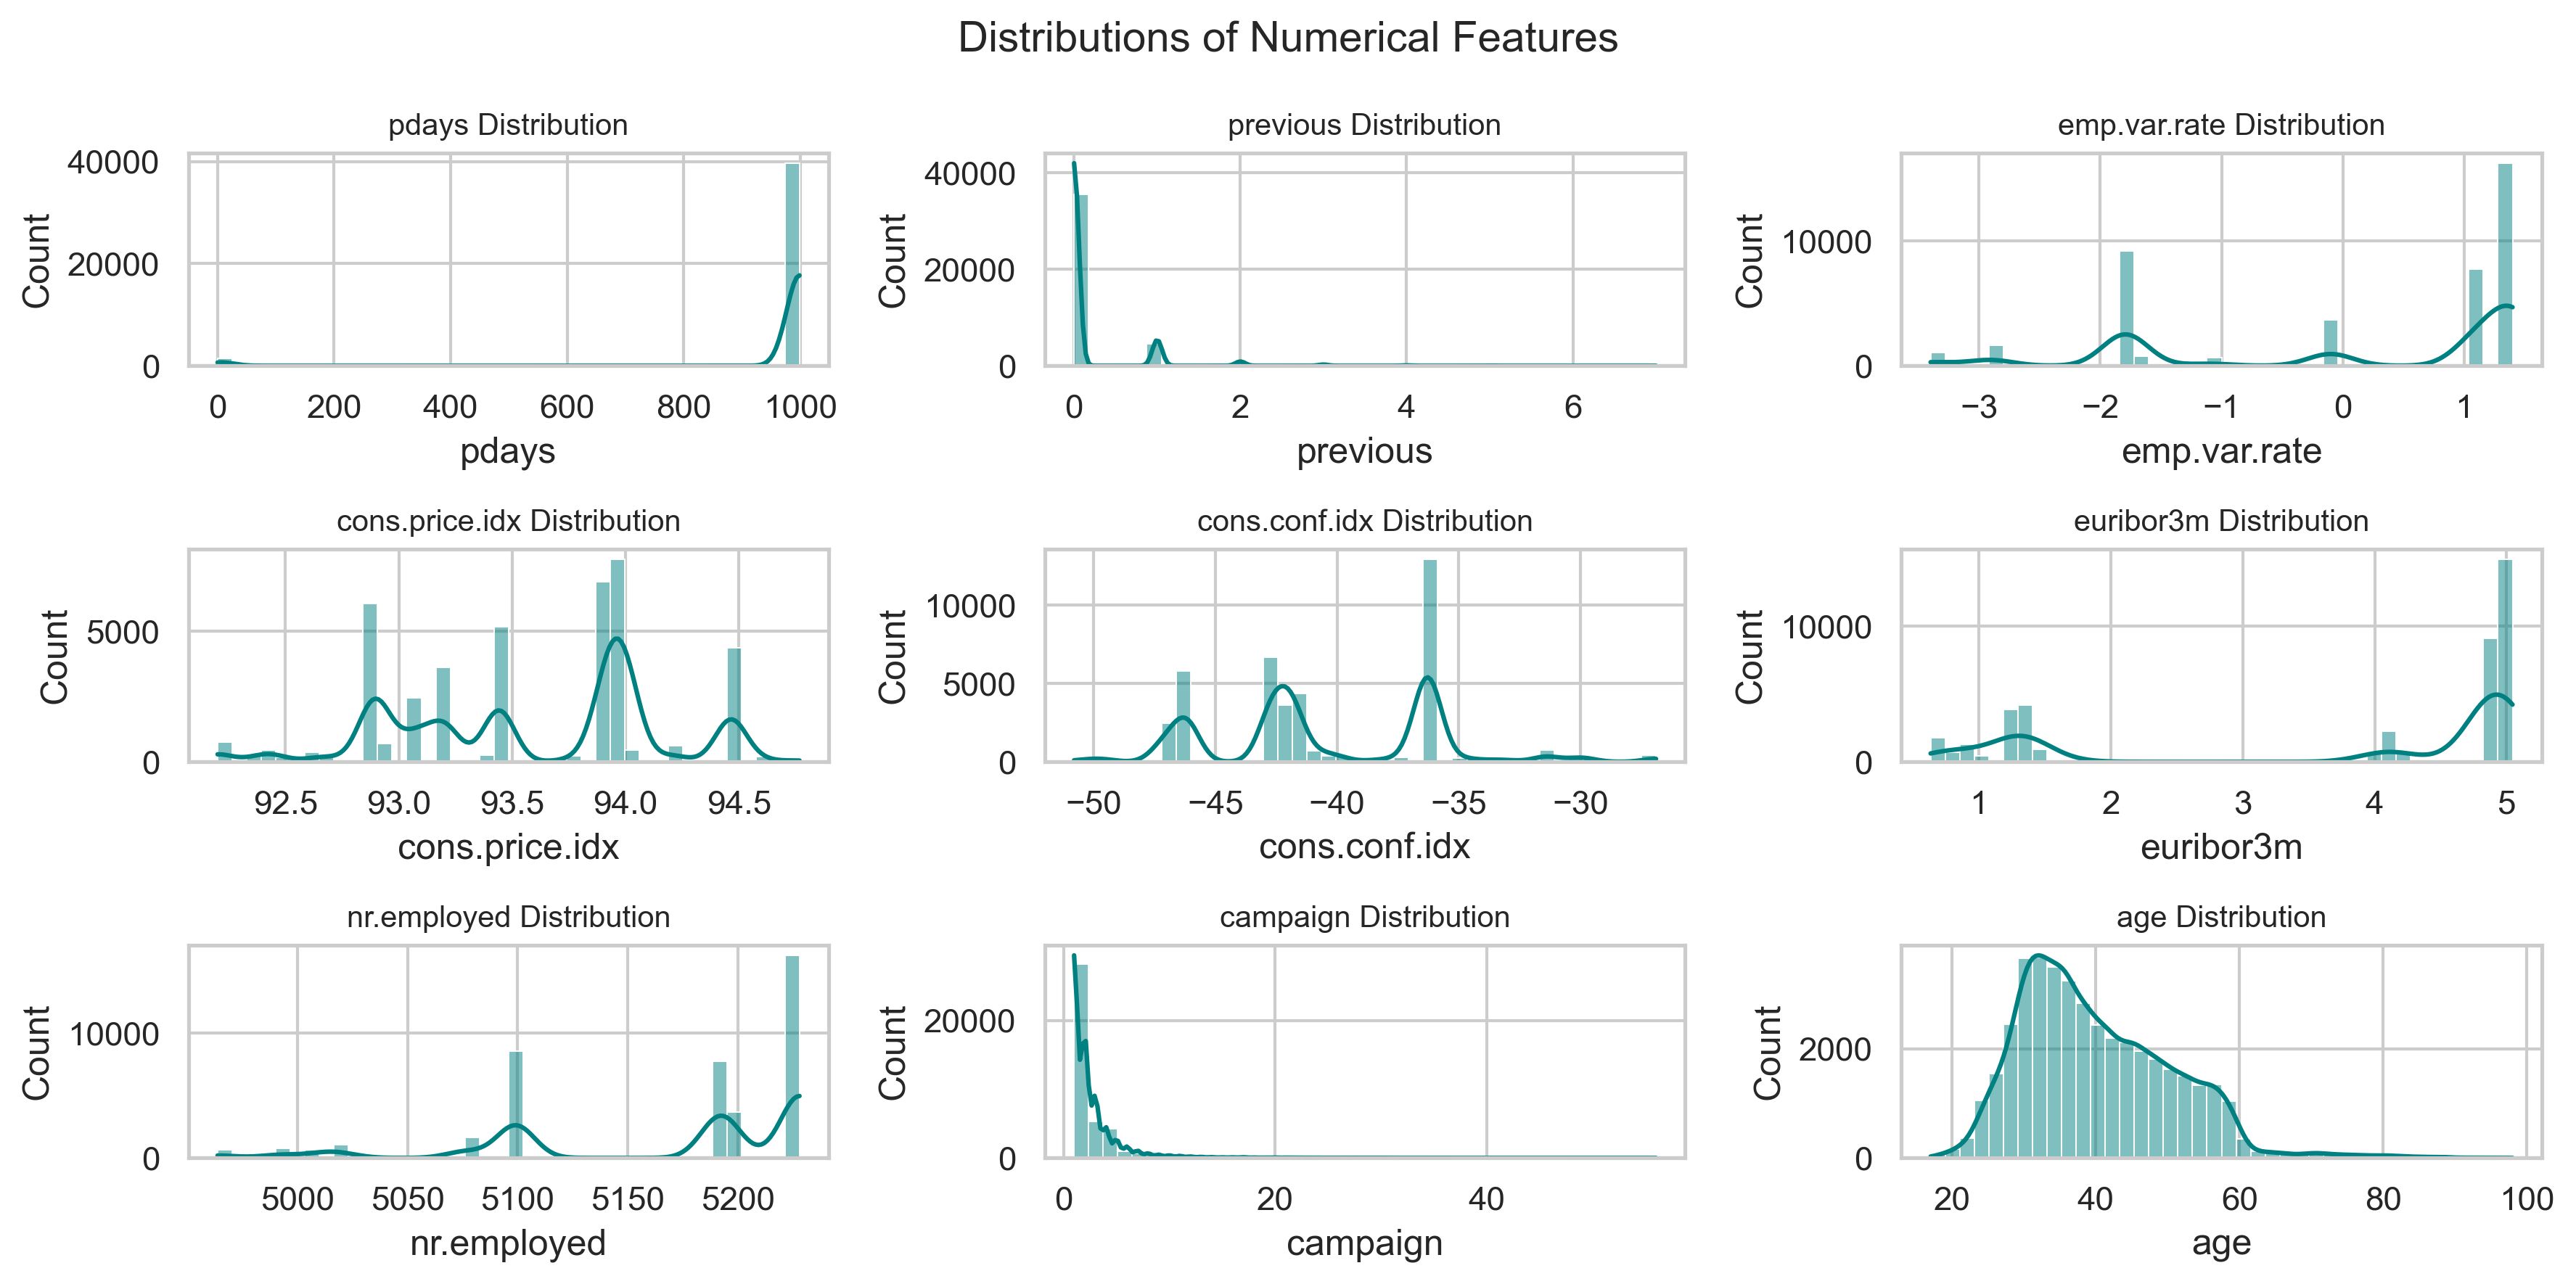

In [144]:
num_cols = ['pdays','previous','emp.var.rate','cons.price.idx',
            'cons.conf.idx','euribor3m','nr.employed','campaign','age']

fig, ax = plt.subplots(3,3, figsize=(12,6), dpi=300)
ax_flat = ax.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True,
        ax=ax_flat[i],
        color='teal'
    )

    ax_flat[i].set_title(f"{col} Distribution", fontsize=10)

plt.suptitle("Distributions of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

Age – Customer ages range from 17 to 98, with most clients concentrated between 25–55 years, indicating that the campaign primarily targets the working-age population.

Campaign (Number of Contacts During Campaign) – Most customers were contacted only a few times (1–3 calls). Extremely high values (e.g., >10 contacts) are rare and may represent outliers or persistent follow-up attempts.

Pdays (Days Since Last Contact in Previous Campaign) – The value 999 dominates, meaning most clients were never contacted in previous marketing campaigns, while a small portion were contacted within 0–30 days earlier.

Previous (Number of Previous Campaign Contacts) – The distribution is highly concentrated at 0, indicating that most customers had no prior interactions with earlier campaigns.

Emp.var.rate (Employment Variation Rate) – This macroeconomic indicator reflects changes in employment levels. The clustered distribution suggests the data was collected across specific economic phases.

Cons.price.idx (Consumer Price Index) – Represents the price level of consumer goods (inflation indicator). The relatively narrow range indicates stable inflation levels during the campaign period.

Cons.conf.idx (Consumer Confidence Index) – Measures consumer sentiment about the economy. Negative values suggest moderate economic uncertainty among consumers during the campaign.

Euribor3m (3-Month Euro Interbank Offered Rate) – This interest rate indicator shows clear peaks, reflecting changes in European lending rates during the campaign timeline.

Nr.employed (Number of Employees in the Economy) – Represents the total employment level in the economy, with clustered values indicating economic stability with slight shifts over time.

In [130]:
df['previous_contact'] = (df['pdays'] != 999).astype(int)

In [131]:
df['previous_contact'].value_counts()

previous_contact
0    39673
1     1515
Name: count, dtype: int64

for modeling change to never called and called

1 → contacted before

0 → never contacted

# Univariate Analysis of Categorical Features

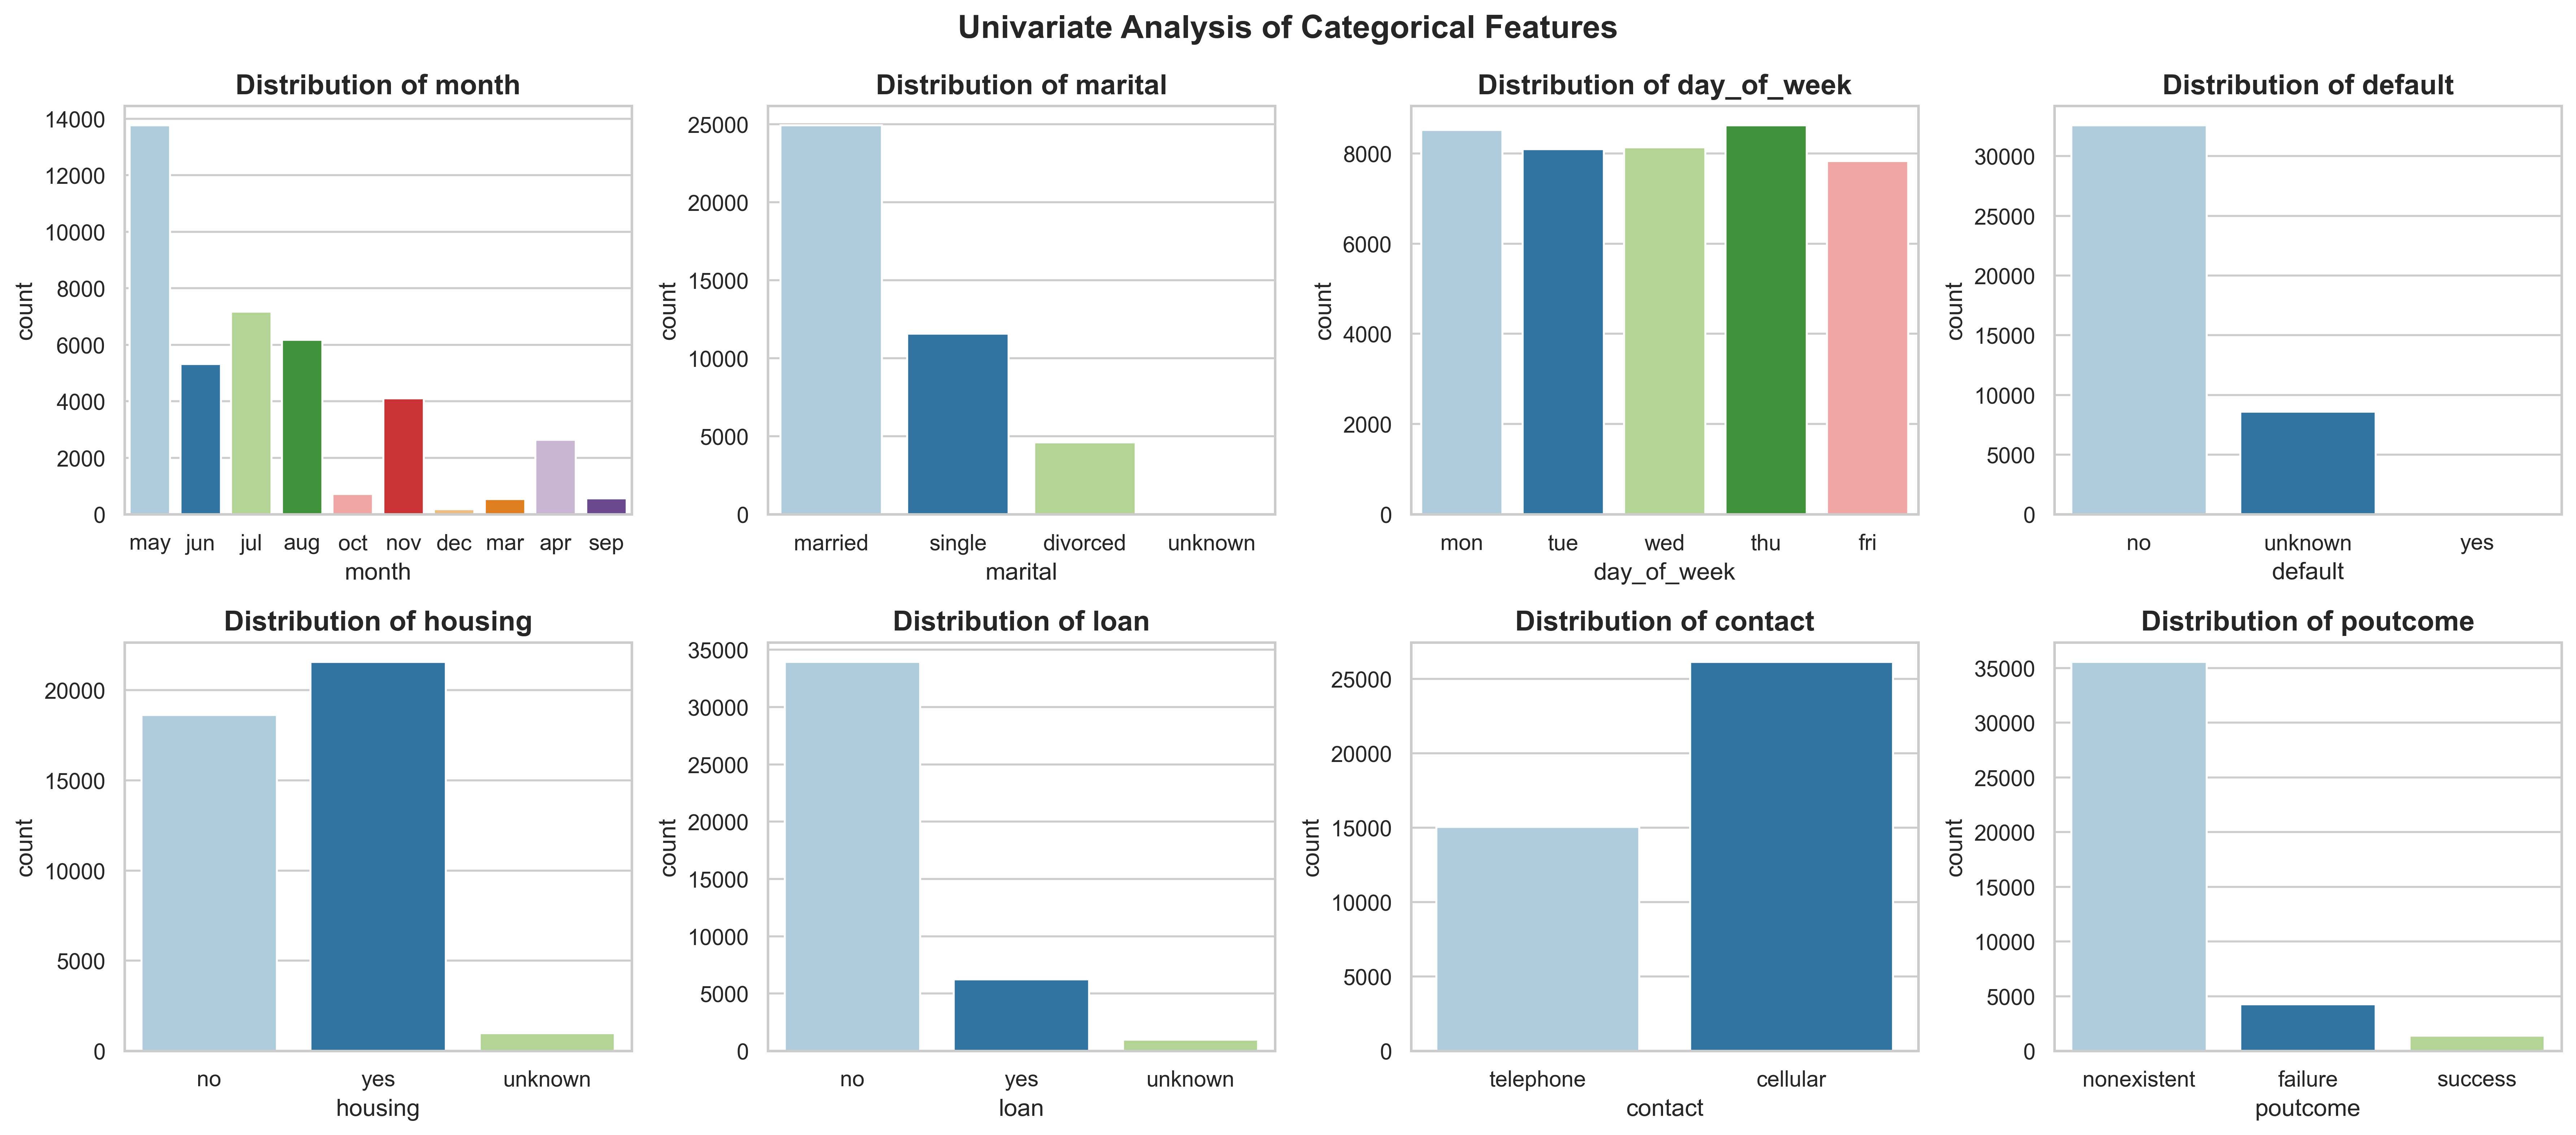

In [133]:
categorical_columns = ['month', 'marital', 'day_of_week', 'default', 'housing', 'loan', 'contact', 'poutcome']
fig, ax = plt.subplots(2,4,figsize=(18,8),dpi=400)
ax_flat = ax.flatten()
for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, ax=ax_flat[i], hue=col, palette ='Paired')
    ax_flat[i].set_title(f"Distribution of {col}",fontsize = 14,fontweight='bold')

    if col in ['job', 'education']:
        ax_flat[i].tick_params(axis='x',rotation=45)

plt.suptitle("Univariate Analysis of Categorical Features",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

Overall, most customers have no credit default, no personal loans, and many have housing loans. 
The majority of marketing contacts occur via cellular phones and many customers have not been 
contacted in previous campaigns.

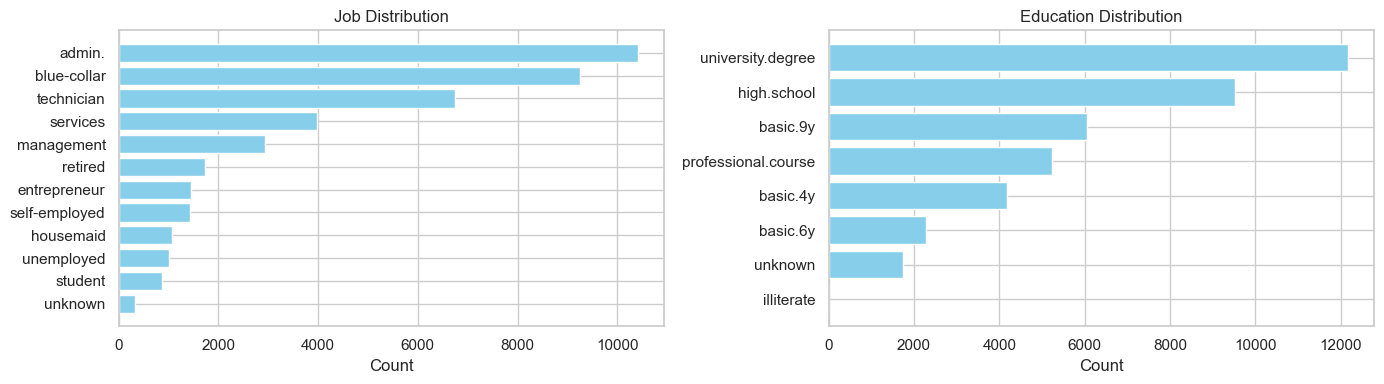

In [134]:
import matplotlib.pyplot as plt

cols = ['job', 'education']

fig, ax = plt.subplots(1, 2, figsize=(14,4))

for i, col in enumerate(cols):

    counts = df[col].value_counts().sort_values(ascending=True)

    ax[i].barh(counts.index, counts.values, color="skyblue")

    ax[i].set_title(f"{col.capitalize()} Distribution")
    ax[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

**Observation** :
Customers are mostly from admin and blue-collar jobs → the marketing campaign may primarily target working professionals.

## check for Correlation beteen variables
- Are two numerical features carrying the same information?

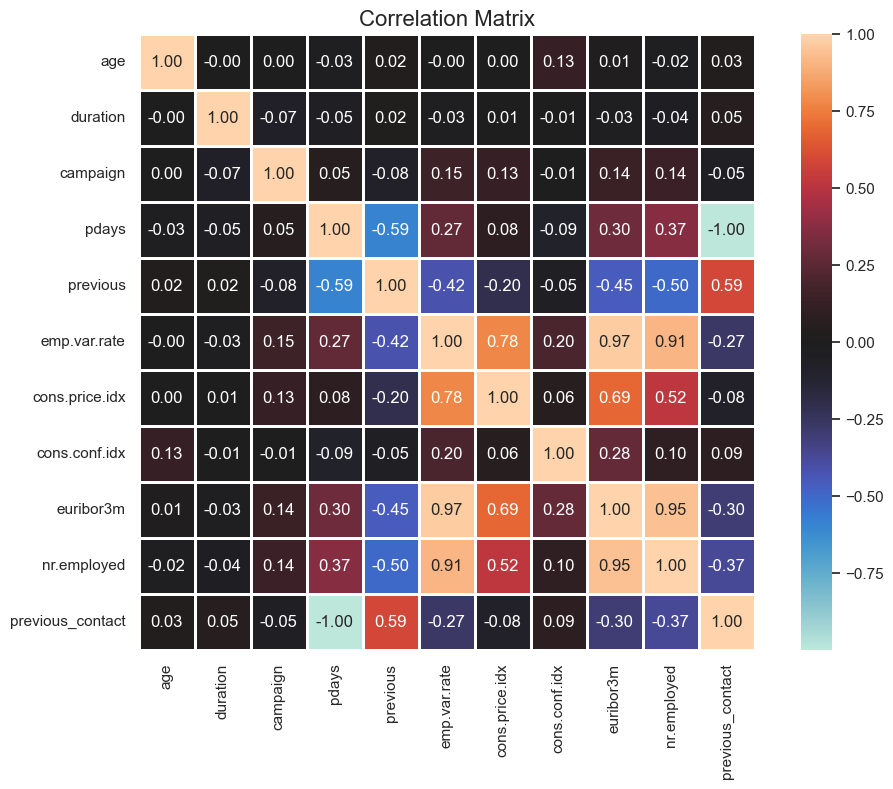

In [135]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=1, center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()


Several economic indicators (emp.var.rate, euribor3m, nr.employed) are highly correlated, suggesting potential redundancy. 
For certain models sensitive to multicollinearity, one or more of these variables may be removed or combined.

### Previous Campaign Outcome vs Subscription
| Value       | Meaning                    |
| ----------- | -------------------------- |
| success     | customer subscribed before |
| failure     | customer rejected before   |
| nonexistent | never contacted            |


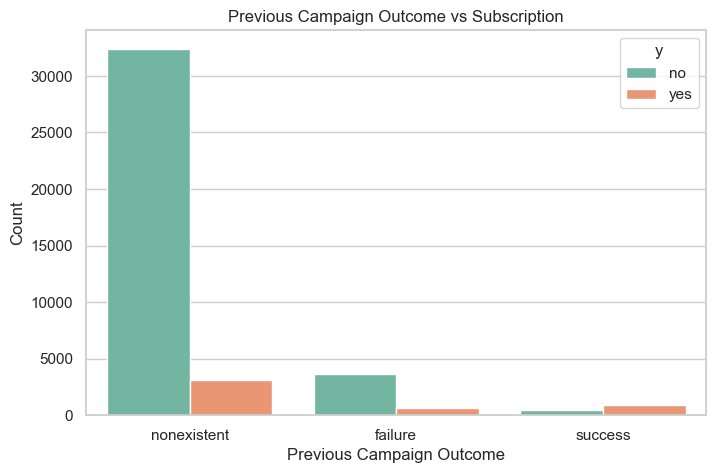

In [136]:
sns.countplot(data=df, x="poutcome", hue="y", palette="Set2")

plt.title("Previous Campaign Outcome vs Subscription")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Count")
plt.show()

Previous campaign success appears to positively influence the likelihood of subscription, making `poutcome` a potentially strong predictor for the target variable.

## Check Target Distribution

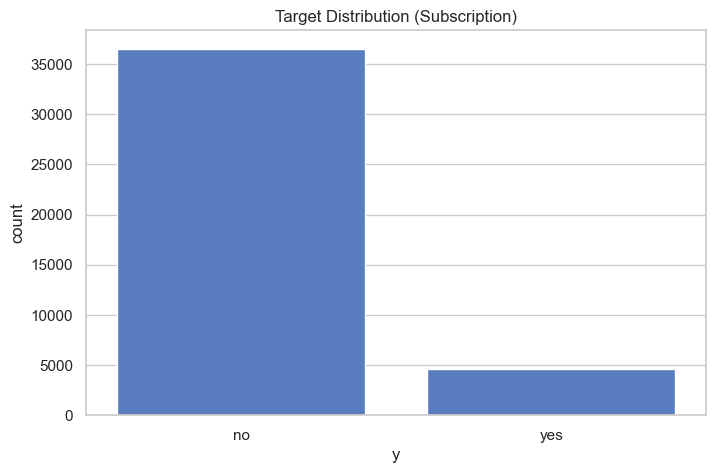

In [137]:
sns.countplot(data=df, x='y')
plt.title("Target Distribution (Subscription)")
plt.show()

**Observation** :
Most customers did not subscribe to the term deposit, indicating that the dataset is highly imbalanced. This suggests that predicting positive subscriptions may be more challenging for the model.


 ## Job and Marital Status vs Target

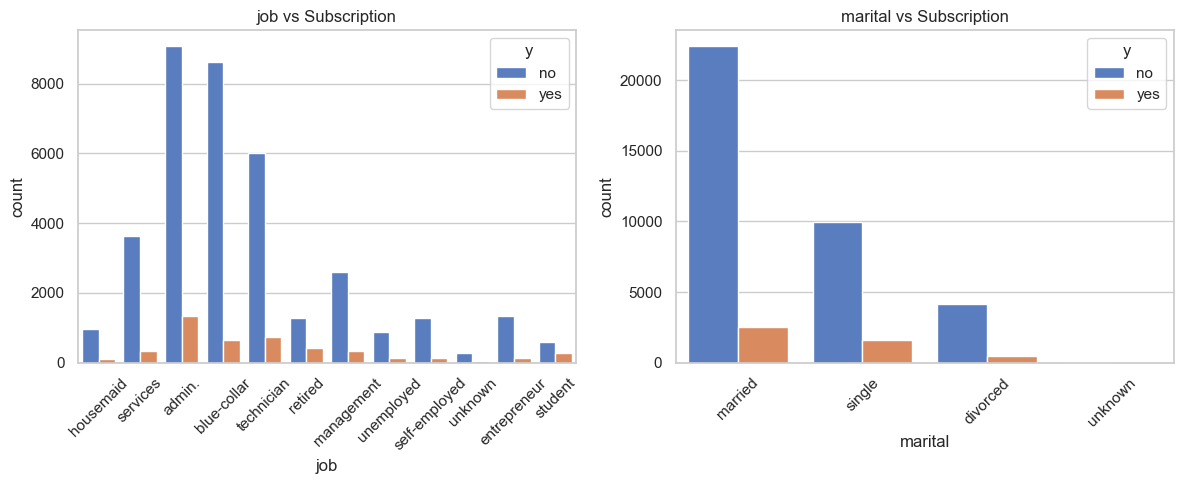

In [138]:
cols = ['job', 'marital']
plt.figure(figsize=(12, 5)) 

for i, col in enumerate(cols):
    plt.subplot(1, 2, i + 1)  
    sns.countplot(x=col, hue='y', data=df)  
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Subscription")

plt.tight_layout() 
plt.show()


Job vs Subscription

Observation :
Most customers work in admin., blue-collar, and technician roles, indicating that the bank mainly targets working professionals. However, across all job categories, the number of customers who did not subscribe is much higher than those who subscribed.

Marital Status vs Subscription

Observation :
The majority of customers are married, followed by single and divorced individuals. Similar to the overall trend, non-subscriptions dominate across all marital groups, suggesting marital status may have limited influence on subscription decisions.

---
## 📌 EDA Summary

- **Dataset** — 41,188 rows · 20 features · no missing values
- **Target (`y`)** — Imbalanced: ~88.7% `no` / ~11.3% `yes` → use F1-score or ROC-AUC
- **Economic features** — `emp.var.rate`, `euribor3m`, `nr.employed` are highly correlated (same macro cycle)
- **Data leakage** — `duration` is a strong predictor but unknown before a call ends; exclude from production
- **Encoding needed** — `job`, `education`, `marital` + handle `unknown` category values
- **Skewness** — `campaign`, `pdays`, `previous` are right-skewed; `pdays = 999` means "never contacted"

> **Next:** sklearn `Pipeline` → preprocessing + baseline model + cross-validation